Initialize Earth Engine

In [ ]:
import ee

In [ ]:
!earthengine authenticate

E0000 00:00:1775833715.131031    5334 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775833715.134999    5334 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775833715.145900    5334 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775833715.145950    5334 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775833715.145953    5334 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775833715.145955    5334 computation_placer.cc:177] computation placer already registered. Please check linka

In [ ]:
ee.Initialize(project="ee-basantbrucesingh")

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/gdrive', force_remount=True)

%ls

%cd 'gdrive/MyDrive/JP/Code'

import os
os.getcwd()

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/gdrive
gdrive/  sample_data/
/content/gdrive/MyDrive/JP/Code


'/content/gdrive/MyDrive/JP/Code'

Sample points

In [ ]:
import rasterio
import numpy as np
import random

from rasterio.transform import xy
from pyproj import Transformer

def tiff_to_tvt(image_path, agb_width, num_tiffs, train_size = 500000, val_size = 150000, test_size = 150000, block_width = 1000, k = 0):
    AGB_WIDTH = agb_width
    with rasterio.open(image_path) as src:
        agb = src.read(1)
        transform = src.transform
        crs = src.crs
        nodata = src.nodata
        bounds = src.bounds

    to_wgs84 = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    agb_maps = []
    agb_coords = []
    valid_indices = []

    for i in range(agb.shape[0]//AGB_WIDTH):
        for j in range(agb.shape[1]//AGB_WIDTH):
            agb_map = agb[AGB_WIDTH*i:AGB_WIDTH*(i+1), AGB_WIDTH*j:AGB_WIDTH*(j+1)]
            if((agb_map == int(nodata)).sum() == 0):
                valid_indices.append((i,j))

    valid_indices_train = valid_indices[:int(len(valid_indices) * (train_size / (train_size + val_size + test_size)))]
    valid_indices_val = valid_indices[int(len(valid_indices) * (train_size / (train_size + val_size + test_size))):int(len(valid_indices) * ((train_size + val_size) / (train_size + val_size + test_size)))]
    valid_indices_test = valid_indices[int(len(valid_indices) * ((train_size + val_size) / (train_size + val_size + test_size))):]

    valid_indices_train = random.sample(valid_indices_train, train_size // num_tiffs)
    valid_indices_val = random.sample(valid_indices_val, val_size // num_tiffs)
    valid_indices_test = random.sample(valid_indices_test, test_size // num_tiffs)

    train_maps = []
    train_coords = []
    val_maps = []
    val_coords = []
    test_maps = []
    test_coords = []

    for i, j in valid_indices_train:
        agb_map = agb[AGB_WIDTH*i:AGB_WIDTH*(i+1), AGB_WIDTH*j:AGB_WIDTH*(j+1)]
        if((agb_map == int(nodata)).sum() == 0):
            train_maps.append(agb_map)
            x0, y0 = xy(transform, AGB_WIDTH*i, AGB_WIDTH*j, offset='ul')
            x1, y1 = xy(transform, AGB_WIDTH*(i+1) - 1, AGB_WIDTH*(j+1) - 1, offset='lr')
            #x0, y0 = to_wgs84.transform(x0, y0)
            #x1, y1 = to_wgs84.transform(x1, y1)

            xmin = min(x0, x1)
            xmax = max(x0, x1)
            ymin = min(y0, y1)
            ymax = max(y0, y1)

            train_coords.append([xmin, xmax, ymin, ymax])
            k += 1

    for i, j in valid_indices_val:
        agb_map = agb[AGB_WIDTH*i:AGB_WIDTH*(i+1), AGB_WIDTH*j:AGB_WIDTH*(j+1)]
        if((agb_map == int(nodata)).sum() == 0):
            val_maps.append(agb_map)
            x0, y0 = xy(transform, AGB_WIDTH*i, AGB_WIDTH*j, offset='ul')
            x1, y1 = xy(transform, AGB_WIDTH*(i+1) - 1, AGB_WIDTH*(j+1) - 1, offset='lr')
            #x0, y0 = to_wgs84.transform(x0, y0)
            #x1, y1 = to_wgs84.transform(x1, y1)

            xmin = min(x0, x1)
            xmax = max(x0, x1)
            ymin = min(y0, y1)
            ymax = max(y0, y1)

            val_coords.append([xmin, xmax, ymin, ymax])
            k += 1

    for i, j in valid_indices_test:
        agb_map = agb[AGB_WIDTH*i:AGB_WIDTH*(i+1), AGB_WIDTH*j:AGB_WIDTH*(j+1)]
        if((agb_map == int(nodata)).sum() == 0):
            test_maps.append(agb_map)
            x0, y0 = xy(transform, AGB_WIDTH*i, AGB_WIDTH*j, offset='ul')
            x1, y1 = xy(transform, AGB_WIDTH*(i+1) - 1, AGB_WIDTH*(j+1) - 1, offset='lr')
            #x0, y0 = to_wgs84.transform(x0, y0)
            #x1, y1 = to_wgs84.transform(x1, y1)

            xmin = min(x0, x1)
            xmax = max(x0, x1)
            ymin = min(y0, y1)
            ymax = max(y0, y1)

            test_coords.append([xmin, xmax, ymin, ymax])
            k += 1

    return train_maps, train_coords, val_maps, val_coords, test_maps, test_coords

In [ ]:
import os
tiff_dir = "Forest_AGB_NW_USA_V2_2443/data"
import geopandas as gpd
import random

agb_maps_train = []
agb_maps_val = []
agb_maps_test = []
agb_coords_train = []
agb_coords_val = []
agb_coords_test = []
agb_years = []
agb_maps = []
agb_coords = []

i = 0
# initialize split size here
TRAIN_SIZE = 500000
VAL_SIZE = 150000
TEST_SIZE = 150000
maxlength = TRAIN_SIZE + VAL_SIZE + TEST_SIZE


num_tiffs = 0
for tiff in os.listdir(tiff_dir):
    if(tiff[-4:] != '.tif'):
        continue
    if(tiff[-10:-4] == 'StdDev'):
      continue
    num_tiffs += 1

print(num_tiffs)

count = 0
train_tiffs = (num_tiffs * TRAIN_SIZE) // (TRAIN_SIZE + VAL_SIZE + TEST_SIZE)
val_tiffs = (num_tiffs * VAL_SIZE) // (TRAIN_SIZE + VAL_SIZE + TEST_SIZE)
test_tiffs = (num_tiffs * TEST_SIZE) // (TRAIN_SIZE + VAL_SIZE + TEST_SIZE)

split_indices = [0 for i in range(train_tiffs)] + [1 for i in range(val_tiffs)] + [2 for i in range(test_tiffs)]
random.shuffle(split_indices)
print(split_indices)

for tiff in os.listdir(tiff_dir):
    if(tiff[-4:] != '.tif'):
        continue
    if(tiff[-10:-4] == 'StdDev'):
      continue

    print(tiff)

    # account for rounding error
    if(count > len(split_indices)):
      break

    count += 1

    train_maps_this, train_coords_this, val_maps_this, val_coords_this, test_maps_this, test_coords_this = tiff_to_tvt(os.path.join(tiff_dir, tiff), 1, 176)
    print("train mean", np.array(train_maps_this).mean())
    print("val mean", np.array(val_maps_this).mean())
    print("test mean", np.array(test_maps_this).mean())

    agb_maps_train += train_maps_this
    agb_coords_train += train_coords_this
    agb_maps_val += val_maps_this
    agb_coords_val += val_coords_this
    agb_maps_test += test_maps_this
    agb_coords_test += test_coords_this

print("Reached end!")

try:
  np.save('map_train_3.npy', np.array(agb_maps_train))
  np.save('coords_train_3.npy', np.array(agb_coords_train))
  np.save('map_val_3.npy', np.array(agb_maps_val))
  np.save('coords_val_3.npy', np.array(agb_coords_val))
  np.save('map_test_3.npy', np.array(agb_maps_test))
  np.save('coords_test_3.npy', np.array(agb_coords_test))
except Exception as e:
  print("saving did not work")

176
[0, 0, 0, 1, 0, 1, 2, 2, 1, 0, 0, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 2, 2, 1, 0, 0, 0, 2, 0, 0, 0, 1, 2, 0, 0, 2, 1, 2, 0, 1, 0, 2, 0, 0, 0, 1, 2, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 1, 1, 0, 2, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 2, 0, 1, 0, 1, 1, 2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 0, 0, 2, 0, 1, 0, 2, 1, 0, 0, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 0, 1, 1, 2, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 1, 0, 0]
HUC10Addition.tif
train mean 230.4644366197183
val mean 186.07042253521126
test mean 105.61971830985915
GlacierPeak2015_2018-02-21.tif
train mean 371.99788732394364
val mean 237.05164319248826
test mean 111.39553990610328
OLC_WEST_METRO_2012.tif
train mean 62.239788732394366
val mean 93.50586854460094
test mean 81.42605633802818
TeanawayBathy2015_2018-03-02.tif
train mean 134.51514084507042
val mean 84.16666666666667
test mean 73.13028169014085
Entiat_2013.tif
tr

In [ ]:
import numpy as np

agb_maps_train = np.load('map_train_3.npy')
agb_coords_train = np.load('coords_train_3.npy')
agb_coords_val = np.load('coords_val_3.npy')
agb_maps_val = np.load('map_val_3.npy')
agb_coords_test = np.load('coords_test_3.npy')
agb_maps_test = np.load('map_test_3.npy')

In [ ]:
print(agb_maps_train.shape)
print(agb_coords_train.shape)
print(agb_maps_val.shape)
print(agb_coords_val.shape)
print(agb_maps_test.shape)
print(agb_coords_test.shape)

print(agb_maps_train.mean())
print(agb_maps_val.mean())
print(agb_maps_test.mean())

(499840, 1, 1)
(499840, 4)
(149952, 1, 1)
(149952, 4)
(149952, 1, 1)
(149952, 4)
159.93599551856593
159.10682751813914
152.87155223004694


Capture images

In [ ]:
import time

def coords_to_image(coords, resolution, agb_width):
    x0, x1, y0, y1 = coords
    bands = ['R', 'G', 'B', 'N']
    size_m = agb_width * 30

    aoi = ee.Geometry.Rectangle(
        [x0, y0, x1, y1],
        proj="EPSG:5070",
        geodesic=False
    ).transform("EPSG:4326", 1)

    collection = ee.ImageCollection('USDA/NAIP/DOQQ') \
    .filterBounds(aoi)
    #.filter(ee.Filter.calendarRange(year, year, "year")

    def select_bands(image):
        return image.select(bands)

    collection = collection.map(select_bands)

    image = ee.Image(collection.sort('system:time_start', False).first()).toFloat().reproject(crs="EPSG:5070", scale=resolution)

    image = image.select(bands).clipToBoundsAndScale(
        geometry=aoi,
        width = size_m / resolution,
        height = size_m / resolution
    )

    time2 = time.perf_counter()

    try:

        rect = image.sampleRectangle(region=aoi, defaultValue=0)
        return rect

    except Exception as e:
        print(f"Patch skipped due to error: {e}")

In [ ]:
images_train = []
images_val = []
images_test = []
agb_maps_train_filtered = []
agb_maps_val_filtered = []
agb_maps_test_filtered = []
bands = ['R', 'G', 'B', 'N']
j = 0
k = 0

rects = []
for i in range(len(agb_coords_train)):
    print(k, i)
    rect = coords_to_image(agb_coords_train[i], 1, 1)
    rects.append(rect)

tot_out = []
BATCH_SIZE = 1000
for i in range((len(rects) - 1) // BATCH_SIZE + 1):
  out = ee.List(rects[i*BATCH_SIZE:(i+1)*BATCH_SIZE]).getInfo()
  tot_out += out


for i in range(len(agb_coords_train)):
    image = tot_out[i]['properties']
    image = np.stack([np.array(image.get(band)) for band in bands])
    image = image.transpose(1, 2, 0)
    missing = (image < 1e-9).sum() != 0
    if(not missing):
        j += 1
        images_train.append(image)
        agb_maps_train_filtered.append(agb_maps_train[i])

print(np.array(images_train).shape)
print(np.array(agb_maps_train_filtered).shape)

np.save('X_train_8.npy', images_train)
np.save('Y_train_8.npy', agb_maps_train_filtered)


k += 1
j = 0

rects = []
for i in range(len(agb_coords_val)):
    print(k, i)
    rect = coords_to_image(agb_coords_val[i], 1, 1)
    rects.append(rect)

tot_out = []
BATCH_SIZE = 1000
for i in range((len(rects) - 1) // BATCH_SIZE + 1):
  out = ee.List(rects[i*BATCH_SIZE:(i+1)*BATCH_SIZE]).getInfo()
  tot_out += out


for i in range(len(agb_coords_val)):
    image = tot_out[i]['properties']
    image = np.stack([np.array(image.get(band)) for band in bands])
    image = image.transpose(1, 2, 0)
    missing = (image < 1e-9).sum() != 0
    if(not missing):
        j += 1
        images_val.append(image)
        agb_maps_val_filtered.append(agb_maps_val[i])

print(np.array(images_val).shape)
print(np.array(agb_maps_val_filtered).shape)

np.save('X_val_8.npy', images_val)
np.save('Y_val_8.npy', agb_maps_val_filtered)

k += 1
j = 0

rects = []
for i in range(len(agb_coords_test)):
    print(k, i)
    rect = coords_to_image(agb_coords_test[i], 1, 1)
    rects.append(rect)

tot_out = []
BATCH_SIZE = 1000
for i in range((len(rects) - 1) // BATCH_SIZE + 1):
  out = ee.List(rects[i*BATCH_SIZE:(i+1)*BATCH_SIZE]).getInfo()
  tot_out += out


for i in range(len(agb_coords_test)):
    image = tot_out[i]['properties']
    image = np.stack([np.array(image.get(band)) for band in bands])
    image = image.transpose(1, 2, 0)
    missing = (image < 1e-9).sum() != 0
    if(not missing):
        j += 1
        images_test.append(image)
        agb_maps_test_filtered.append(agb_maps_test[i])

print(np.array(images_test).shape)
print(np.array(agb_maps_test_filtered).shape)


np.save('X_test_8.npy', images_test)
np.save('Y_test_8.npy', agb_maps_test_filtered)





Streaming output truncated to the last 5000 lines.
1 144952
1 144953
1 144954
1 144955
1 144956
1 144957
1 144958
1 144959
1 144960
1 144961
1 144962
1 144963
1 144964
1 144965
1 144966
1 144967
1 144968
1 144969
1 144970
1 144971
1 144972
1 144973
1 144974
1 144975
1 144976
1 144977
1 144978
1 144979
1 144980
1 144981
1 144982
1 144983
1 144984
1 144985
1 144986
1 144987
1 144988
1 144989
1 144990
1 144991
1 144992
1 144993
1 144994
1 144995
1 144996
1 144997
1 144998
1 144999
1 145000
1 145001
1 145002
1 145003
1 145004
1 145005
1 145006
1 145007
1 145008
1 145009
1 145010
1 145011
1 145012
1 145013
1 145014
1 145015
1 145016
1 145017
1 145018
1 145019
1 145020
1 145021
1 145022
1 145023
1 145024
1 145025
1 145026
1 145027
1 145028
1 145029
1 145030
1 145031
1 145032
1 145033
1 145034
1 145035
1 145036
1 145037
1 145038
1 145039
1 145040
1 145041
1 145042
1 145043
1 145044
1 145045
1 145046
1 145047
1 145048
1 145049
1 145050
1 145051
1 145052
1 145053
1 145054
1 145055
1 145056
1 14

Streaming output truncated to the last 5000 lines.
2 144954
2 144955
2 144956
2 144957
2 144958
2 144959
2 144960
2 144961
2 144962
2 144963
2 144964
2 144965
2 144966
2 144967
2 144968
2 144969
2 144970
2 144971
2 144972
2 144973
2 144974
2 144975
2 144976
2 144977
2 144978
2 144979
2 144980
2 144981
2 144982
2 144983
2 144984
2 144985
2 144986
2 144987
2 144988
2 144989
2 144990
2 144991
2 144992
2 144993
2 144994
2 144995
2 144996
2 144997
2 144998
2 144999
2 145000
2 145001
2 145002
2 145003
2 145004
2 145005
2 145006
2 145007
2 145008
2 145009
2 145010
2 145011
2 145012
2 145013
2 145014
2 145015
2 145016
2 145017
2 145018
2 145019
2 145020
2 145021
2 145022
2 145023
2 145024
2 145025
2 145026
2 145027
2 145028
2 145029
2 145030
2 145031
2 145032
2 145033
2 145034
2 145035
2 145036
2 145037
2 145038
2 145039
2 145040
2 145041
2 145042
2 145043
2 145044
2 145045
2 145046
2 145047
2 145048
2 145049
2 145050
2 145051
2 145052
2 145053
2 145054
2 145055
2 145056
2 145057
2 145058
2 14

Normalize all values

In [ ]:
import numpy as np

X_train = np.stack(np.load("X_train_8.npy").transpose(0, 3, 1, 2))
Y_train = np.stack(np.load("Y_train_8.npy"))
X_mean = X_train.mean()
X_std = X_train.std()
X_train = (X_train - X_mean) / X_std
Y_mean = Y_train.mean()
Y_std = Y_train.std()
Y_train = (Y_train - Y_mean) / Y_std

X_val = np.stack(np.load("X_val_8.npy").transpose(0, 3, 1, 2))
X_val = (X_val - X_mean) / X_std
Y_val = np.stack(np.load("Y_val_8.npy"))
Y_val = (Y_val - Y_mean) / Y_std


X_test = np.stack(np.load("X_test_8.npy").transpose(0, 3, 1, 2))
X_test = (X_test - X_mean) / X_std
Y_test = np.stack(np.load("Y_test_8.npy"))
Y_test = (Y_test - Y_mean) / Y_std

'\nfor i in range(len(X_test)):\n  mean = X_test[i].mean()\n  std = X_test[i].std()\n  X_test[i] = (X_test[i] - mean) / std\n'

In [ ]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(431219, 4, 30, 30)
(129604, 4, 30, 30)
(129818, 4, 30, 30)


In [ ]:
print(X_train.mean())
print(X_val.mean())

print(Y_train.mean())
print(Y_val.mean())

-2.625221822142791e-16
-0.012921219407529234
-2.636406042442843e-17
-0.006706110375358163


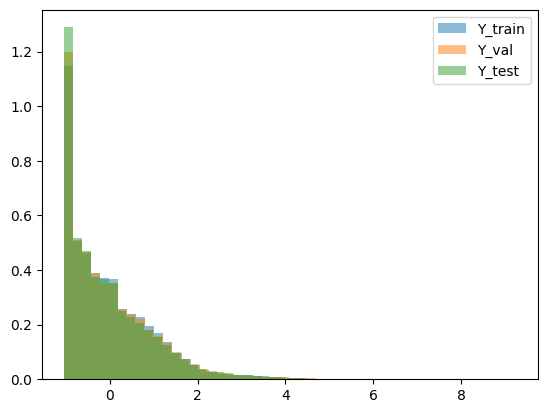

In [ ]:
import matplotlib.pyplot as plt

plt.hist(Y_train.flatten(), density=True, bins=50, alpha=0.5, label="Y_train")
plt.hist(Y_val.flatten(), density=True, bins=50, alpha=0.5, label="Y_val")
plt.hist(Y_test.flatten(), density=True, bins=50, alpha=0.5, label="Y_test")
plt.legend()
plt.show()

In [ ]:
ybar = Y_train.mean()
mse_mean_train = ((Y_train - ybar)**2).mean()
mse_mean_val   = ((Y_val   - ybar)**2).mean()
print("mean-baseline train:", mse_mean_train)
print("mean-baseline val:", mse_mean_val)

mean-baseline train: 1.0000000000000002
mean-baseline val: 1.034063894429594


Visualize examples

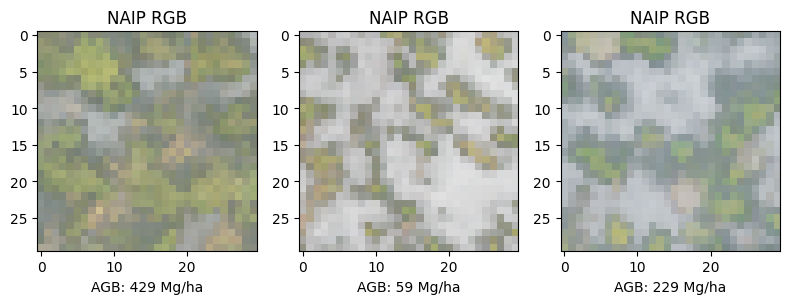

In [ ]:
import random

fig, ax = plt.subplots(1, 3, figsize=(8, 4))
indices = [i for i in range(len(X_train))]
random.shuffle(indices)
i1, i2, i3 = indices[:3]

ax[0].imshow((X_train[i1].transpose(1, 2, 0) * X_std + X_mean) / 255)
ax[0].set_title("NAIP RGB")
ax[0].set_xlabel("AGB: " + str(int(Y_train[i1,0,0] * Y_std + Y_mean)) + " Mg/ha")

ax[1].imshow((X_train[i2].transpose(1, 2, 0) * X_std + X_mean) / 255)
ax[1].set_title("NAIP RGB")
ax[1].set_xlabel("AGB: " + str(int(Y_train[i2,0,0] * Y_std + Y_mean)) + " Mg/ha")

ax[2].imshow((X_train[i3].transpose(1, 2, 0) * X_std + X_mean) / 255)
ax[2].set_title("NAIP RGB")
ax[2].set_xlabel("AGB: " + str(int(Y_train[i3,0,0] * Y_std + Y_mean)) + " Mg/ha")

plt.tight_layout()
plt.show()

Set up PyTorch

In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms

class AGBDataset:
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_dataset = AGBDataset(X_train, Y_train)
val_dataset = AGBDataset(X_val, Y_val)
test_dataset = AGBDataset(X_test, Y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
import torch

USE_GPU = True
dtype = torch.float32

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(device)

cuda


In [ ]:
def check_mse(loader, model):
    total_error = 0
    num_samples = 0
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype).squeeze(1)
            output = model(x)
            error = torch.nn.functional.mse_loss(output, y) * y.shape[0]
            total_error += error.item()
            num_samples += y.shape[0]

    return total_error / num_samples

In [ ]:
def train(model, optimizer, loader_train, loader_val, epochs=1, print_every=10):
    """
    Train a model using the PyTorch Module API.

    Inputs:
    - model: A PyTorch Module giving the model to train.
    - optimizer: An Optimizer object we will use to train the model
    - loader_train: A dataloader containing the train dataset
    - loader_val: A dataloader containing the validation dataset
    - epochs: (Optional) An integer giving the number of epochs to train for
    - print_every: (Optional) An integer specifying how often to print the loss.

    Returns: Nothing, but prints model losses and accuracies during training.
    """
    model = model.to(device=device)
    train_losses = []
    val_losses = []
    for e in range(epochs):
        for t, (x, y) in enumerate(loader_train):
            model.train()
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype).squeeze(1)

            output = model(x)

            loss = torch.nn.functional.mse_loss(output, y)

            optimizer.zero_grad()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            if t % print_every == 0:
                print('Epoch {}, iteration {}, loss = {}'.format(e, t, loss.item()))


        print('Epoch {} done'.format(e))
        train_mse = check_mse(loader_train, model)
        train_losses.append(train_mse)
        print('train mse', train_mse)
        val_mse = check_mse(loader_val, model)
        val_losses.append(val_mse)
        print('val mse: ', val_mse)

    return train_losses, val_losses

Train SmallCNNs

In [ ]:
import torch.nn as nn

def flatten(x):
    N = x.shape[0]
    return x.view(N, -1)

class Flatten(nn.Module):
    def forward(self, x):
        return flatten(x)

model1 = nn.Sequential(
    nn.Conv2d(4, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(16),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.Dropout2d(0.05),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(32),
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.Dropout2d(0.05),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(64),
    nn.Conv2d(64, 16, kernel_size=3, padding=1),
    nn.Dropout2d(0.05),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(16),
    nn.Conv2d(16, 1, kernel_size=3, padding=1),
    Flatten()
)

model1 = model1.to(device=device)

learning_rate = 1e-3
optimizer = torch.optim.Adam(model1.parameters(), lr=learning_rate)

In [ ]:
train_losses, val_losses = train(model1, optimizer, train_loader, val_loader, epochs=20, print_every=100)

train_losses = np.array(train_losses)
val_losses = np.array(val_losses)

np.save("train_losses_model1.npy", train_losses)
np.save("val_losses_model1.npy", val_losses)

torch.save(model1.state_dict(), 'model_weights.pth')

Epoch 0, iteration 0, loss = 1.0986363887786865
Epoch 0, iteration 100, loss = 0.9164483547210693
Epoch 0, iteration 200, loss = 0.9912923574447632
Epoch 0, iteration 300, loss = 2.404508113861084
Epoch 0, iteration 400, loss = 1.1803756952285767
Epoch 0, iteration 500, loss = 0.8540378212928772
Epoch 0, iteration 600, loss = 0.3592416048049927
Epoch 0, iteration 700, loss = 0.5926246643066406
Epoch 0, iteration 800, loss = 0.6501545906066895
Epoch 0, iteration 900, loss = 0.7542166709899902
Epoch 0, iteration 1000, loss = 0.6256653666496277
Epoch 0, iteration 1100, loss = 0.47317707538604736
Epoch 0, iteration 1200, loss = 0.6510810852050781
Epoch 0, iteration 1300, loss = 0.41363316774368286
Epoch 0, iteration 1400, loss = 0.5264067649841309
Epoch 0, iteration 1500, loss = 0.5098645687103271
Epoch 0, iteration 1600, loss = 0.5156775712966919
Epoch 0, iteration 1700, loss = 1.010926604270935
Epoch 0, iteration 1800, loss = 0.4670839309692383
Epoch 0, iteration 1900, loss = 0.354124337

In [ ]:
total_params = sum(p.numel() for p in model1.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 33361


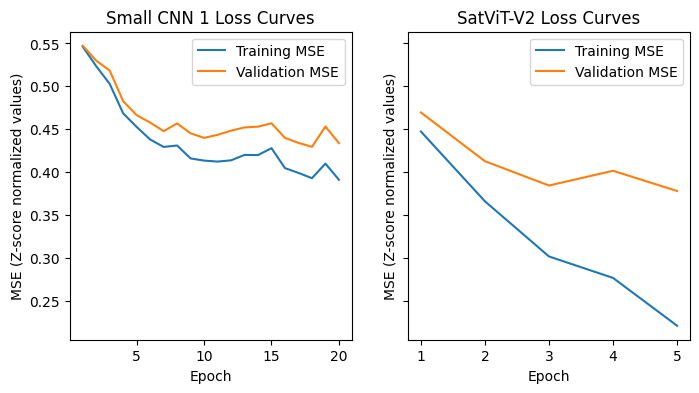

In [ ]:
train_losses_1 = np.load("train_losses_model1.npy")
val_losses_1 = np.load("val_losses_model1.npy")
train_losses_2 = np.load("train_losses_satvit_2.npy")
val_losses_2 = np.load("val_losses_satvit_2.npy")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

ax[0].set_title("Small CNN 1 Loss Curves")
ax[1].set_title("SatViT-V2 Loss Curves")
ax[0].plot(range(1, 21), train_losses_1, label='Training MSE')
ax[0].plot(range(1, 21), val_losses_1, label='Validation MSE')
ax[1].plot(range(1,6), train_losses_2, label='Training MSE')
ax[1].plot(range(1,6), val_losses_2, label='Validation MSE')
ax[0].set_xlabel('Epoch')
ax[1].set_xlabel('Epoch')
ax[0].set_ylabel('MSE (Z-score normalized values)')
ax[1].set_ylabel('MSE (Z-score normalized values)')
ax[0].legend()
ax[1].legend()
plt.legend()
plt.show()

In [ ]:
import torch.nn as nn

def flatten(x):
    N = x.shape[0]
    return x.view(N, -1)

class Flatten(nn.Module):
    def forward(self, x):
        return flatten(x)


model2 = nn.Sequential(
    nn.Conv2d(4, 6, kernel_size=3, padding=1),
    nn.Conv2d(6, 12, kernel_size=3, padding=1),
    nn.Conv2d(12, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(16),
    nn.Conv2d(16, 24, kernel_size=3, padding=1),
    nn.Conv2d(24, 28, kernel_size=3, padding=1),
    nn.Conv2d(28, 32, kernel_size=3, padding=1),
    nn.Dropout2d(0.05),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(32),
    nn.Conv2d(32, 42, kernel_size=3, padding=1),
    nn.Conv2d(42, 52, kernel_size=3, padding=1),
    nn.Conv2d(52, 64, kernel_size=3, padding=1),
    nn.Dropout2d(0.05),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(64),
    nn.Conv2d(64, 48, kernel_size=3, padding=1),
    nn.Conv2d(48, 32, kernel_size=3, padding=1),
    nn.Conv2d(32, 16, kernel_size=3, padding=1),
    nn.Dropout2d(0.05),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(16),
    nn.Conv2d(16, 1, kernel_size=3, padding=1),
    Flatten()
)

model2 = model2.to(device=device)

learning_rate = 5e-3
optimizer = torch.optim.Adam(model2.parameters(), lr=learning_rate)

In [ ]:
learning_rate = 5e-3
optimizer = torch.optim.Adam(model2.parameters(), lr=learning_rate)

In [ ]:
train_losses, val_losses = train(model2, optimizer, train_loader, val_loader, epochs=60, print_every=100)
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)
np.save("train_losses_model2.npy", train_losses)
np.save("val_losses_model2.npy", val_losses)
torch.save(model2.state_dict(), 'model2_weights.pth')

Streaming output truncated to the last 5000 lines.
Epoch 23, iteration 10600, loss = 0.2891942858695984
Epoch 23, iteration 10700, loss = 0.5692520141601562
Epoch 23, iteration 10800, loss = 0.587274432182312
Epoch 23, iteration 10900, loss = 0.5413714051246643
Epoch 23, iteration 11000, loss = 0.38216453790664673
Epoch 23, iteration 11100, loss = 0.4729698896408081
Epoch 23, iteration 11200, loss = 0.28081977367401123
Epoch 23, iteration 11300, loss = 0.5895213484764099
Epoch 23, iteration 11400, loss = 0.5854276418685913
Epoch 23, iteration 11500, loss = 0.380707323551178
Epoch 23, iteration 11600, loss = 0.16649869084358215
Epoch 23, iteration 11700, loss = 0.3597487211227417
Epoch 23, iteration 11800, loss = 0.6951989531517029
Epoch 23, iteration 11900, loss = 0.8425027132034302
Epoch 23, iteration 12000, loss = 0.33879727125167847
Epoch 23, iteration 12100, loss = 0.28581100702285767
Epoch 23, iteration 12200, loss = 0.544572114944458
Epoch 23, iteration 12300, loss = 0.4566546678

In [ ]:
total_params = sum(p.numel() for p in model2.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 128717


In [ ]:
index = 5500
image = X_val[index].transpose(1, 2, 0)

model1.eval()
with torch.no_grad():
  prediction1 = model1(torch.from_numpy(X_val[index]).to(device=device, dtype=dtype).unsqueeze_(0))

model2.eval()
with torch.no_grad():
  prediction2 = model2(torch.from_numpy(X_val[index]).to(device=device, dtype=dtype).unsqueeze_(0))

print(Y_train[index] * Y_std + Y_mean)
print(prediction1.cpu() * Y_std + Y_mean)
print(prediction2.cpu() * Y_std + Y_mean)

fig, ax = plt.subplots(1, 4, figsize=(8, 4))

ax[0].imshow(image)
ax[0].set_title("NAIP NGB")
ax[0].axis("off")

ax[1].imshow((Y_train[index] * Y_std + Y_mean))
ax[1].set_title("Ground Truth")
ax[1].axis("off")

ax[2].imshow(prediction1.cpu() * Y_std + Y_mean)
ax[2].set_title("Model 1 Prediction")
ax[2].axis("off")

ax[3].imshow(prediction2.cpu() * Y_std + Y_mean)
ax[3].set_title("Model 2 Prediction")
ax[3].axis("off")

plt.tight_layout()
plt.show()

SatViT

In [ ]:
def images_to_patches_chw(images, patch_hw):
    """
    images: (B, C, H, W)
    returns: (B, num_patches, C * patch_hw * patch_hw)
    """
    B, C, H, W = images.shape
    assert H % patch_hw == 0 and W % patch_hw == 0

    patches = images.unfold(2, patch_hw, patch_hw).unfold(3, patch_hw, patch_hw)

    patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()

    patches = patches.view(B, -1, C * patch_hw * patch_hw)
    return patches

def check_mse_satvit(loader, model):
    total_error = 0
    num_samples = 0
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)
            x = images_to_patches_chw(x, patch_hw=5)
            y = y.to(device=device, dtype=dtype).view(-1)
            output = model(x)
            error = torch.nn.functional.mse_loss(output, y) * y.shape[0]
            total_error += error.item()
            num_samples += y.shape[0]

    return total_error / num_samples

def train_satvit(model, optimizer, loader_train, loader_val, epochs=1, print_every=10):
    """
    Train a model using the PyTorch Module API.

    Inputs:
    - model: A PyTorch Module giving the model to train.
    - optimizer: An Optimizer object we will use to train the model
    - loader_train: A dataloader containing the train dataset
    - loader_val: A dataloader containing the validation dataset
    - epochs: (Optional) An integer giving the number of epochs to train for
    - print_every: (Optional) An integer specifying how often to print the loss.

    Returns: Nothing, but prints model losses and accuracies during training.
    """
    model = model.to(device=device)
    train_losses = []
    val_losses = []
    for e in range(epochs):
        for t, (x, y) in enumerate(loader_train):
            model.train()
            x = x.to(device=device, dtype=dtype)
            x = images_to_patches_chw(x, patch_hw=5)
            y = y.to(device=device, dtype=dtype).view(-1)

            output = model(x)

            loss = torch.nn.functional.mse_loss(output, y)

            optimizer.zero_grad()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            if t % print_every == 0:
                print('Epoch {}, iteration {}, loss = {}'.format(e, t, loss.item()))

        train_mse = check_mse_satvit(loader_train, model)
        train_losses.append(train_mse)
        val_mse = check_mse_satvit(loader_val, model)
        val_losses.append(val_mse)
        print('Epoch {} done'.format(e))
        print('train mse', train_mse)
        print('val mse: ', val_mse)
    return train_losses, val_losses


In [ ]:
from SatViT_model import SatViT
import torch
import torch.nn as nn

patch_hw = 5
num_channels = 4
io_dim = patch_hw * patch_hw * num_channels
num_patches = (30 // patch_hw) * (30 // patch_hw)
io_dim = int(patch_hw*patch_hw*num_channels)
satvit_model = SatViT(
    io_dim=io_dim,
    num_patches=num_patches,
    encoder_dim=768,
    encoder_depth=12,
    encoder_num_heads=12,
    decoder_dim=512,
    decoder_depth=1,
    decoder_num_heads=8,
).cuda()

model_dict = satvit_model.state_dict()
checkpoint = torch.load("SatViT_V2.pt")

filtered_checkpoint = {
    k: v for k, v in checkpoint.items()
    if k in model_dict and model_dict[k].shape == v.shape
}

model_dict.update(filtered_checkpoint)
satvit_model.load_state_dict(model_dict)

for param in satvit_model.parameters():
    param.requires_grad = True

class SatViTRegressor(nn.Module):
    def __init__(self, satvit, encoder_dim=768):
        super().__init__()
        self.satvit = satvit
        self.head = nn.Linear(encoder_dim, 1)

    def forward(self, x):
        feats = self.satvit.encode(x)
        pooled = feats.mean(dim=1)
        out = self.head(pooled)
        return out.squeeze(1)

satvit_model = SatViTRegressor(satvit_model).to(device)

for param in satvit_model.parameters():
    param.requires_grad = False

'''
for name, param in satvit_model.named_parameters():
    print(name, param.shape)
'''

for block in satvit_model.satvit.encoder.layers[-34:]:
    for param in block.parameters():
        param.requires_grad = True

learning_rate = 5e-5
optimizer = torch.optim.Adam(satvit_model.parameters(), lr=learning_rate)


In [ ]:
train_losses, val_losses = train_satvit(satvit_model, optimizer, train_loader, val_loader, epochs=5, print_every=100)
model_dict = satvit_model.state_dict()
torch.save(model_dict, 'satvit_model_0.5.pth')
train_losses_2, val_losses_2 = train_satvit(satvit_model, optimizer, train_loader, val_loader, epochs=5, print_every=100)
train_losses = np.array(train_losses + train_losses_2)
val_losses = np.array(val_losses + val_losses_2)
np.save("train_losses_satvit.npy", train_losses)
np.save("val_losses_satvit.npy", val_losses)
model_dict = satvit_model.state_dict()
torch.save(model_dict, 'satvit_model.pth')

Epoch 0, iteration 0, loss = 0.7258559465408325
Epoch 0, iteration 100, loss = 0.6886489391326904
Epoch 0, iteration 200, loss = 1.5308033227920532
Epoch 0, iteration 300, loss = 0.8829724192619324
Epoch 0, iteration 400, loss = 0.5384219884872437
Epoch 0, iteration 500, loss = 0.722456693649292
Epoch 0, iteration 600, loss = 0.3752313256263733
Epoch 0, iteration 700, loss = 0.4413130283355713
Epoch 0, iteration 800, loss = 0.33413809537887573
Epoch 0, iteration 900, loss = 0.48845741152763367
Epoch 0, iteration 1000, loss = 0.5615279078483582
Epoch 0, iteration 1100, loss = 0.46134674549102783
Epoch 0, iteration 1200, loss = 0.7840524315834045
Epoch 0, iteration 1300, loss = 0.4419991075992584
Epoch 0, iteration 1400, loss = 0.6137930154800415
Epoch 0, iteration 1500, loss = 1.3807438611984253
Epoch 0, iteration 1600, loss = 1.2633593082427979
Epoch 0, iteration 1700, loss = 0.49849608540534973
Epoch 0, iteration 1800, loss = 1.122855544090271
Epoch 0, iteration 1900, loss = 0.5228452

In [ ]:
from SatViT_model import SatViT
#from einops import rearrange
import torch
import torch.nn as nn

patch_hw = 5
num_channels = 4
io_dim = patch_hw * patch_hw * num_channels
num_patches = (30 // patch_hw) * (30 // patch_hw)
io_dim = int(patch_hw*patch_hw*num_channels)
satvit_model = SatViT(
    io_dim=io_dim,
    num_patches=num_patches,
    encoder_dim=768,
    encoder_depth=12,
    encoder_num_heads=12,
    decoder_dim=512,
    decoder_depth=1,
    decoder_num_heads=8,
).cuda()

model_dict = satvit_model.state_dict()
checkpoint = torch.load("SatViT_V2.pt")

filtered_checkpoint = {
    k: v for k, v in checkpoint.items()
    if k in model_dict and model_dict[k].shape == v.shape
}

model_dict.update(filtered_checkpoint)
satvit_model.load_state_dict(model_dict)

for param in satvit_model.parameters():
    param.requires_grad = True

class SatViTRegressor(nn.Module):
    def __init__(self, satvit, encoder_dim=768):
        super().__init__()
        self.satvit = satvit
        self.head = nn.Linear(encoder_dim, 1)

    def forward(self, x):
        feats = self.satvit.encode(x)
        pooled = feats.mean(dim=1)
        out = self.head(pooled)
        return out.squeeze(1)

satvit_model = SatViTRegressor(satvit_model).to(device)

learning_rate = 5e-5
optimizer = torch.optim.Adam(satvit_model.parameters(), lr=learning_rate)

In [ ]:
train_losses, val_losses = train_satvit(satvit_model, optimizer, train_loader, val_loader, epochs=5, print_every=100)
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)
np.save("train_losses_satvit_2.npy", train_losses)
np.save("val_losses_satvit_2.npy", val_losses)
model_dict = satvit_model.state_dict()
torch.save(model_dict, 'satvit_model_2.pth')

Epoch 0, iteration 0, loss = 1.2184922695159912
Epoch 0, iteration 100, loss = 0.39432355761528015
Epoch 0, iteration 200, loss = 0.7547701597213745
Epoch 0, iteration 300, loss = 0.8353841304779053
Epoch 0, iteration 400, loss = 0.4299503564834595
Epoch 0, iteration 500, loss = 0.3139604330062866
Epoch 0, iteration 600, loss = 0.455670028924942
Epoch 0, iteration 700, loss = 0.4564805030822754
Epoch 0, iteration 800, loss = 0.5637154579162598
Epoch 0, iteration 900, loss = 0.5790503621101379
Epoch 0, iteration 1000, loss = 0.6179661154747009
Epoch 0, iteration 1100, loss = 0.30523979663848877
Epoch 0, iteration 1200, loss = 0.5890398025512695
Epoch 0, iteration 1300, loss = 0.9564186930656433
Epoch 0, iteration 1400, loss = 0.8622989058494568
Epoch 0, iteration 1500, loss = 0.5625460743904114
Epoch 0, iteration 1600, loss = 0.6154501438140869
Epoch 0, iteration 1700, loss = 0.6840115785598755
Epoch 0, iteration 1800, loss = 1.1129183769226074
Epoch 0, iteration 1900, loss = 0.58266067

In [ ]:
print(check_mse_satvit(test_loader, satvit_model))

0.3800845632979582


In [ ]:
total_params = sum(p.numel() for p in satvit_model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 88750181


ResNet18

In [ ]:
!pip install torchgeo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.6/863.6 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 128.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
import torch.nn as nn
from torchgeo.models import resnet18, ResNet18_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"

resnet_model2 = resnet18(weights=ResNet18_Weights.SENTINEL2_RGB_MOCO)
#resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 1)

for param in resnet_model2.parameters():
    param.requires_grad = False

in_features = resnet_model2.fc.in_features
resnet_model2.fc = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(resnet_model2.fc.in_features, 1),
)

old_conv = resnet_model2.conv1
new_conv = nn.Conv2d(
    4,
    old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False,
)

with torch.no_grad():
    new_conv.weight[:, :3] = old_conv.weight
    new_conv.weight[:, 3:4] = old_conv.weight.mean(dim=1, keepdim=True)

resnet_model2.conv1 = new_conv

for param in resnet_model2.layer4.parameters():
    param.requires_grad = True

for param in resnet_model2.layer3.parameters():
    param.requires_grad = True

'''
for param in resnet_model2.layer2.parameters():
    param.requires_grad = True

for param in resnet_model2.layer1.parameters():
    param.requires_grad = True
'''

for param in resnet_model2.fc.parameters():
    param.requires_grad = True

resnet_model2 = resnet_model2.to(device)

learning_rate = 1e-4
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model2.parameters()),
    lr=learning_rate
)

KeyboardInterrupt: 

In [ ]:
train_losses, val_losses = train(resnet_model2, optimizer, train_loader, val_loader, epochs=5, print_every=100)
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)
np.save('train_losses_resnet18.npy', train_losses)
np.save('val_losses_resnet18.npy', val_losses)
model_weights = copy.deepcopy(resnet_model2.state_dict())
torch.save(model_weights, 'resnet18_weights.pth')

Epoch 0, iteration 0, loss = 0.8513429760932922
Epoch 0, iteration 100, loss = 0.8407468795776367
Epoch 0, iteration 200, loss = 0.3904429078102112
Epoch 0, iteration 300, loss = 1.1090506315231323
Epoch 0, iteration 400, loss = 0.5373426675796509
Epoch 0, iteration 500, loss = 0.33603230118751526
Epoch 0, iteration 600, loss = 0.9514789581298828
Epoch 0, iteration 700, loss = 0.5933332443237305
Epoch 0, iteration 800, loss = 1.1127865314483643
Epoch 0, iteration 900, loss = 1.463415265083313
Epoch 0, iteration 1000, loss = 0.6920638084411621
Epoch 0, iteration 1100, loss = 0.46487095952033997
Epoch 0, iteration 1200, loss = 0.48426052927970886
Epoch 0, iteration 1300, loss = 0.49741795659065247
Epoch 0, iteration 1400, loss = 0.6651783585548401
Epoch 0, iteration 1500, loss = 0.8060030937194824
Epoch 0, iteration 1600, loss = 0.42507004737854004
Epoch 0, iteration 1700, loss = 0.36725378036499023
Epoch 0, iteration 1800, loss = 0.34274542331695557
Epoch 0, iteration 1900, loss = 0.240

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training MSE')
plt.plot(val_losses, label='Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torchgeo.models import resnet18, ResNet18_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"

resnet_model2 = resnet18(weights=ResNet18_Weights.SENTINEL2_RGB_MOCO)
#resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 1)

in_features = resnet_model2.fc.in_features
resnet_model2.fc = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(resnet_model2.fc.in_features, 1),
)

old_conv = resnet_model2.conv1
new_conv = nn.Conv2d(
    4,
    old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False,
)

with torch.no_grad():
    new_conv.weight[:, :3] = old_conv.weight
    new_conv.weight[:, 3:4] = old_conv.weight.mean(dim=1, keepdim=True)

resnet_model2.conv1 = new_conv

resnet_model2 = resnet_model2.to(device)

learning_rate = 1e-4
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model2.parameters()),
    lr=learning_rate
)

Downloading: "https://hf.co/torchgeo/resnet18_sentinel2_rgb_moco/resolve/e1c032e7785fd0625224cdb6699aa138bb304eec/resnet18_sentinel2_rgb_moco-e3a335e3.pth" to /root/.cache/torch/hub/checkpoints/resnet18_sentinel2_rgb_moco-e3a335e3.pth


100%|██████████| 42.7M/42.7M [00:00<00:00, 674MB/s]


In [ ]:
train_losses, val_losses = train(resnet_model2, optimizer, train_loader, val_loader, epochs=5, print_every=100)
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)
np.save('train_losses_resnet18_2.npy', train_losses)
np.save('val_losses_resnet18_2.npy', val_losses)
model_dict = resnet_model2.state_dict()
torch.save(model_dict, 'resnet18_weights_2.pth')

Epoch 0, iteration 0, loss = 1.0252076387405396
Epoch 0, iteration 100, loss = 0.7035261988639832
Epoch 0, iteration 200, loss = 1.1572680473327637
Epoch 0, iteration 300, loss = 0.37541407346725464
Epoch 0, iteration 400, loss = 0.516934335231781
Epoch 0, iteration 500, loss = 0.4474548399448395
Epoch 0, iteration 600, loss = 0.35845324397087097
Epoch 0, iteration 700, loss = 0.4859760105609894
Epoch 0, iteration 800, loss = 0.44060999155044556
Epoch 0, iteration 900, loss = 0.31261277198791504
Epoch 0, iteration 1000, loss = 0.6292722225189209
Epoch 0, iteration 1100, loss = 0.564548909664154
Epoch 0, iteration 1200, loss = 1.1479839086532593
Epoch 0, iteration 1300, loss = 0.24610808491706848
Epoch 0, iteration 1400, loss = 0.26694801449775696
Epoch 0, iteration 1500, loss = 0.8601130247116089
Epoch 0, iteration 1600, loss = 0.499390184879303
Epoch 0, iteration 1700, loss = 0.5315332412719727
Epoch 0, iteration 1800, loss = 1.2832285165786743
Epoch 0, iteration 1900, loss = 0.385941

In [ ]:
total_params = sum(p.numel() for p in resnet_model2.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 11180161


ResNet50

In [ ]:
!pip install satlaspretrain-models

In [ ]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import satlaspretrain_models

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_CHECKPOINT_ID = "Sentinel2_Resnet50_SI_RGB"

weights_manager = satlaspretrain_models.Weights()
backbone = weights_manager.get_pretrained_model(
    model_identifier=MODEL_CHECKPOINT_ID
).to(device)

In [ ]:
class SatlasScalarRegressor(nn.Module):
    def __init__(self, backbone, feat_dim, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 1)
        )

    def forward(self, x):
        feats = self.backbone(x)

        if isinstance(feats, (list, tuple)):
            f = feats[-1]
        elif isinstance(feats, dict):
            f = list(feats.values())[-1]
        else:
            f = feats

        pooled = self.pool(f).flatten(1)
        out = self.head(pooled)
        return out

In [ ]:
@torch.no_grad()
def infer_feature_dim(backbone, image_size=64):
    x = torch.zeros((2, 4, image_size, image_size), dtype=torch.float32, device=device).to(device)
    feats = backbone(x)

    if isinstance(feats, (list, tuple)):
        print("Feature shapes:", [f.shape for f in feats])
        f = feats[-1]
    elif isinstance(feats, dict):
        print("Feature shapes:", {k: v.shape for k, v in feats.items()})
        f = list(feats.values())[-1]
    else:
        print("Feature shape:", feats.shape)
        f = feats

    return f.shape[1]

old_conv = backbone.backbone.resnet.conv1
new_conv = nn.Conv2d(
    4,
    old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False,
).to(device)

with torch.no_grad():
    new_conv.weight[:, :3] = old_conv.weight
    new_conv.weight[:, 3:4] = old_conv.weight.mean(dim=1, keepdim=True)

backbone.backbone.resnet.conv1 = new_conv

feat_dim = infer_feature_dim(backbone, image_size=64)
model = SatlasScalarRegressor(backbone, feat_dim=feat_dim, dropout=0.3).to(device)

for param in model.backbone.parameters():
    param.requires_grad = False

'''
for name, param in model.named_parameters():
    print(name, param.shape)
'''

for name, param in model.backbone.named_parameters():
    if "layer3" in name or 'layer4' in name or "norm" in name:
        param.requires_grad = True


optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-4,
)

Feature shapes: [torch.Size([2, 256, 16, 16]), torch.Size([2, 512, 8, 8]), torch.Size([2, 1024, 4, 4]), torch.Size([2, 2048, 2, 2])]


In [ ]:
train_losses, val_losses = train(model, optimizer, train_loader, val_loader, epochs=10, print_every=100)
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)
np.save('train_losses_satlas.npy', train_losses)
np.save('val_losses_satlas.npy', val_losses)
model_weights = copy.deepcopy(model.state_dict())
torch.save(model_weights, 'satlas_weights.pth')


Epoch 0, iteration 0, loss = 0.7180492877960205
Epoch 0, iteration 100, loss = 1.2561801671981812
Epoch 0, iteration 200, loss = 1.4159331321716309
Epoch 0, iteration 300, loss = 0.9630604386329651
Epoch 0, iteration 400, loss = 0.5109118819236755
Epoch 0, iteration 500, loss = 1.1971491575241089
Epoch 0, iteration 600, loss = 0.5341221690177917
Epoch 0, iteration 700, loss = 1.4200760126113892
Epoch 0, iteration 800, loss = 0.7967013120651245
Epoch 0, iteration 900, loss = 0.48951488733291626
Epoch 0, iteration 1000, loss = 1.5738276243209839
Epoch 0, iteration 1100, loss = 1.0448781251907349
Epoch 0, iteration 1200, loss = 0.764009952545166
Epoch 0, iteration 1300, loss = 1.4339221715927124
Epoch 0, iteration 1400, loss = 0.6047313213348389
Epoch 0, iteration 1500, loss = 0.723244309425354
Epoch 0, iteration 1600, loss = 0.4991796314716339
Epoch 0, iteration 1700, loss = 1.151221752166748
Epoch 0, iteration 1800, loss = 0.5349351167678833
Epoch 0, iteration 1900, loss = 0.51211261749

In [ ]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import satlaspretrain_models

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_CHECKPOINT_ID = "Sentinel2_Resnet50_SI_RGB"

weights_manager = satlaspretrain_models.Weights()
backbone = weights_manager.get_pretrained_model(
    model_identifier=MODEL_CHECKPOINT_ID
).to(device)

ModuleNotFoundError: No module named 'satlaspretrain_models'

In [ ]:
class SatlasScalarRegressor(nn.Module):
    def __init__(self, backbone, feat_dim, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 1)
        )

    def forward(self, x):
        feats = self.backbone(x)

        if isinstance(feats, (list, tuple)):
            f = feats[-1]
        elif isinstance(feats, dict):
            f = list(feats.values())[-1]
        else:
            f = feats

        pooled = self.pool(f).flatten(1)
        out = self.head(pooled)
        return out

In [ ]:
@torch.no_grad()
def infer_feature_dim(backbone, image_size=64):
    x = torch.zeros((2, 4, image_size, image_size), dtype=torch.float32, device=device).to(device)
    feats = backbone(x)

    if isinstance(feats, (list, tuple)):
        print("Feature shapes:", [f.shape for f in feats])
        f = feats[-1]
    elif isinstance(feats, dict):
        print("Feature shapes:", {k: v.shape for k, v in feats.items()})
        f = list(feats.values())[-1]
    else:
        print("Feature shape:", feats.shape)
        f = feats

    return f.shape[1]

old_conv = backbone.backbone.resnet.conv1
new_conv = nn.Conv2d(
    4,
    old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False,
).to(device)

with torch.no_grad():
    new_conv.weight[:, :3] = old_conv.weight
    new_conv.weight[:, 3:4] = old_conv.weight.mean(dim=1, keepdim=True)

backbone.backbone.resnet.conv1 = new_conv

feat_dim = infer_feature_dim(backbone, image_size=64)
model = SatlasScalarRegressor(backbone, feat_dim=feat_dim, dropout=0.3).to(device)


optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-4,
)

NameError: name 'backbone' is not defined

In [ ]:
train_losses, val_losses = train(model, optimizer, train_loader, val_loader, epochs=10, print_every=100)
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)
np.save('train_losses_satlas_2.npy', train_losses)
np.save('val_losses_satlas_2.npy', val_losses)
model_weights = copy.deepcopy(model.state_dict())
torch.save(model_weights, 'satlas_weights_2.pth')

Epoch 0, iteration 0, loss = 1.2071404457092285
Epoch 0, iteration 100, loss = 0.7598974704742432
Epoch 0, iteration 200, loss = 0.48844000697135925
Epoch 0, iteration 300, loss = 1.0837371349334717
Epoch 0, iteration 400, loss = 0.8098311424255371
Epoch 0, iteration 500, loss = 0.8108237981796265
Epoch 0, iteration 600, loss = 0.36605238914489746
Epoch 0, iteration 700, loss = 0.7388437986373901
Epoch 0, iteration 800, loss = 0.5143352746963501
Epoch 0, iteration 900, loss = 0.5000836849212646
Epoch 0, iteration 1000, loss = 0.4175156354904175
Epoch 0, iteration 1100, loss = 0.8466709852218628
Epoch 0, iteration 1200, loss = 0.6361649036407471
Epoch 0, iteration 1300, loss = 0.7531870603561401
Epoch 0, iteration 1400, loss = 1.025347352027893
Epoch 0, iteration 1500, loss = 2.2664051055908203
Epoch 0, iteration 1600, loss = 0.6278496980667114
Epoch 0, iteration 1700, loss = 0.8299185037612915
Epoch 0, iteration 1800, loss = 2.173949956893921
Epoch 0, iteration 1900, loss = 0.432015955

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 25562217


In [ ]:
print(Y_std)
print(Y_mean)

155.11886431629637
160.21910444576886


In [ ]:
import math

values = [0.434, 0.422, 0.540, 0.464, 0.709, 0.425, 0.392, 0.378]
for i in range(len(values)):
  values[i] = math.sqrt(values[i]) * Y_std

print(values)

[np.float64(102.19025460865367), np.float64(100.76758304226678), np.float64(113.98862011648305), np.float64(105.663162923437), np.float64(130.61339979246117), np.float64(101.12512733431026), np.float64(97.11977105706544), np.float64(95.36972193123937)]


Qualitative Comparison

In [ ]:
!pip install satlaspretrain-models

In [ ]:
!pip install torchgeo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.6/863.6 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import satlaspretrain_models
from SatViT_model import SatViT
import torch.nn as nn
from torchgeo.models import resnet18, ResNet18_Weights

def flatten(x):
    N = x.shape[0]
    return x.view(N, -1)

class Flatten(nn.Module):
    def forward(self, x):
        return flatten(x)

model1 = nn.Sequential(
    nn.Conv2d(4, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(16),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.Dropout2d(0.05),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(32),
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.Dropout2d(0.05),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(64),
    nn.Conv2d(64, 16, kernel_size=3, padding=1),
    nn.Dropout2d(0.05),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(16),
    nn.Conv2d(16, 1, kernel_size=3, padding=1),
    Flatten()
)

model1.load_state_dict(torch.load('model_weights.pth'))
model1.to(device)

model2 = nn.Sequential(
    nn.Conv2d(4, 6, kernel_size=3, padding=1),
    nn.Conv2d(6, 12, kernel_size=3, padding=1),
    nn.Conv2d(12, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(16),
    nn.Conv2d(16, 24, kernel_size=3, padding=1),
    nn.Conv2d(24, 28, kernel_size=3, padding=1),
    nn.Conv2d(28, 32, kernel_size=3, padding=1),
    nn.Dropout2d(0.05),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(32),
    nn.Conv2d(32, 42, kernel_size=3, padding=1),
    nn.Conv2d(42, 52, kernel_size=3, padding=1),
    nn.Conv2d(52, 64, kernel_size=3, padding=1),
    nn.Dropout2d(0.05),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(64),
    nn.Conv2d(64, 48, kernel_size=3, padding=1),
    nn.Conv2d(48, 32, kernel_size=3, padding=1),
    nn.Conv2d(32, 16, kernel_size=3, padding=1),
    nn.Dropout2d(0.05),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.BatchNorm2d(16),
    nn.Conv2d(16, 1, kernel_size=3, padding=1),
    Flatten()
)

model2.load_state_dict(torch.load('model2_weights.pth'))
model2.to(device)

resnet18_model = resnet18(weights=ResNet18_Weights.SENTINEL2_RGB_MOCO)

in_features = resnet18_model.fc.in_features
resnet18_model.fc = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(resnet18_model.fc.in_features, 1),
)

old_conv = resnet18_model.conv1
new_conv = nn.Conv2d(
    4,
    old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False,
)

resnet18_model.conv1 = new_conv
resnet18_model.load_state_dict(torch.load('resnet18_weights.pth'))
resnet18_model.to(device)

resnet18_model_2 = resnet18(weights=ResNet18_Weights.SENTINEL2_RGB_MOCO)

in_features = resnet18_model_2.fc.in_features
resnet18_model_2.fc = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(resnet18_model_2.fc.in_features, 1),
)

old_conv = resnet18_model_2.conv1
new_conv = nn.Conv2d(
    4,
    old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False,
)

resnet18_model_2.conv1 = new_conv
resnet18_model_2.load_state_dict(torch.load('resnet18_weights_2.pth'))
resnet18_model_2.to(device)

class SatlasScalarRegressor(nn.Module):
    def __init__(self, backbone, feat_dim, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 1)
        )

    def forward(self, x):
        feats = self.backbone(x)

        if isinstance(feats, (list, tuple)):
            f = feats[-1]
        elif isinstance(feats, dict):
            f = list(feats.values())[-1]
        else:
            f = feats

        pooled = self.pool(f).flatten(1)
        out = self.head(pooled)
        return out

MODEL_CHECKPOINT_ID = "Sentinel2_Resnet50_SI_RGB"

weights_manager = satlaspretrain_models.Weights()
backbone = weights_manager.get_pretrained_model(
    model_identifier=MODEL_CHECKPOINT_ID
).to(device)

@torch.no_grad()
def infer_feature_dim(backbone, image_size=64):
    x = torch.zeros((2, 4, image_size, image_size), dtype=torch.float32, device=device).to(device)
    feats = backbone(x)

    if isinstance(feats, (list, tuple)):
        print("Feature shapes:", [f.shape for f in feats])
        f = feats[-1]
    elif isinstance(feats, dict):
        print("Feature shapes:", {k: v.shape for k, v in feats.items()})
        f = list(feats.values())[-1]
    else:
        print("Feature shape:", feats.shape)
        f = feats

    return f.shape[1]

old_conv = backbone.backbone.resnet.conv1
new_conv = nn.Conv2d(
    4,
    old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False,
).to(device)

backbone.backbone.resnet.conv1 = new_conv

feat_dim = infer_feature_dim(backbone, image_size=64)
resnet50_model = SatlasScalarRegressor(backbone, feat_dim=feat_dim, dropout=0.2).to(device)
resnet50_model.load_state_dict(torch.load('satlas_weights.pth'))

resnet50_model_2 = SatlasScalarRegressor(backbone, feat_dim=feat_dim, dropout=0.2).to(device)
resnet50_model_2.load_state_dict(torch.load('satlas_weights_2.pth'))

class SatViTRegressor(nn.Module):
    def __init__(self, satvit, encoder_dim=768):
        super().__init__()
        self.satvit = satvit
        self.head = nn.Linear(encoder_dim, 1)

    def forward(self, x):
        feats = self.satvit.encode(x)
        pooled = feats.mean(dim=1)
        out = self.head(pooled)
        return out.squeeze(1)

patch_hw = 5
num_channels = 4
io_dim = patch_hw * patch_hw * num_channels
num_patches = (30 // patch_hw) * (30 // patch_hw)
io_dim = int(patch_hw*patch_hw*num_channels)
satvit_model = SatViT(
    io_dim=io_dim,
    num_patches=num_patches,
    encoder_dim=768,
    encoder_depth=12,
    encoder_num_heads=12,
    decoder_dim=512,
    decoder_depth=1,
    decoder_num_heads=8,
).cuda()

for param in satvit_model.parameters():
    param.requires_grad = False

for block in satvit_model.encoder.layers[-34:]:
    for param in block.parameters():
        param.requires_grad = True

satvit_model = SatViTRegressor(satvit_model).to(device)
satvit_model.load_state_dict(torch.load('satvit_model.pth'))

satvit_model_2 = SatViT(
    io_dim=io_dim,
    num_patches=num_patches,
    encoder_dim=768,
    encoder_depth=12,
    encoder_num_heads=12,
    decoder_dim=512,
    decoder_depth=1,
    decoder_num_heads=8,
).cuda()

satvit_model_2 = SatViTRegressor(satvit_model_2).to(device)
satvit_model_2.load_state_dict(torch.load('satvit_model_2.pth'))


Feature shapes: [torch.Size([2, 256, 16, 16]), torch.Size([2, 512, 8, 8]), torch.Size([2, 1024, 4, 4]), torch.Size([2, 2048, 2, 2])]


<All keys matched successfully>

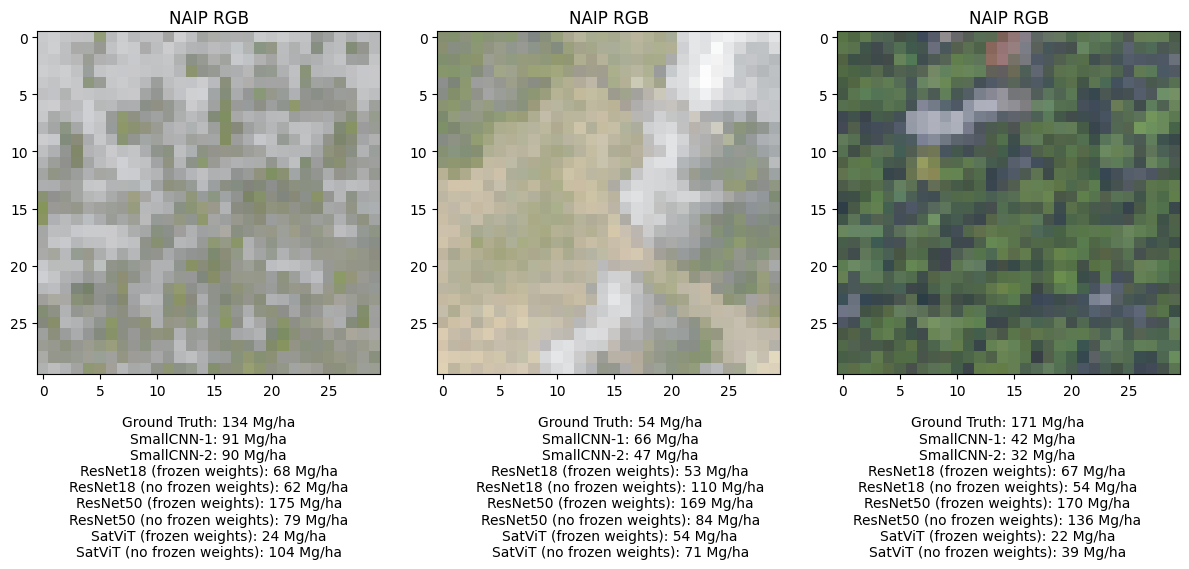

In [ ]:
import random
import matplotlib.pyplot as plt
import torch

fig, ax = plt.subplots(1, 3, figsize=(12, 6))
indices = [i for i in range(len(X_val))]
random.shuffle(indices)
i1, i2, i3 = indices[:3]

img1 = X_val[i1]
x1 = torch.from_numpy(img1).to(device=device, dtype=dtype).unsqueeze(0)
img2 = X_val[i2]
x2 = torch.from_numpy(img2).to(device=device, dtype=dtype).unsqueeze(0)
img3 = X_val[i3]
x3 = torch.from_numpy(img3).to(device=device, dtype=dtype).unsqueeze(0)
preds1 = []
preds2 = []
preds3 = []
models = [model1, model2, resnet18_model, resnet18_model_2, resnet50_model, resnet50_model_2, satvit_model, satvit_model_2]

def images_to_patches_chw(images, patch_hw):
    """
    images: (B, C, H, W)
    returns: (B, num_patches, C * patch_hw * patch_hw)
    """
    B, C, H, W = images.shape
    assert H % patch_hw == 0 and W % patch_hw == 0

    patches = images.unfold(2, patch_hw, patch_hw).unfold(3, patch_hw, patch_hw)

    patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()

    patches = patches.view(B, -1, C * patch_hw * patch_hw)
    return patches

for model in models:
  model.eval()
  with torch.no_grad():
      if isinstance(model, SatViTRegressor):
          x1_processed = images_to_patches_chw(x1, patch_hw=5)
          x2_processed = images_to_patches_chw(x2, patch_hw=5)
          x3_processed = images_to_patches_chw(x3, patch_hw=5)
          pred1 = model(x1_processed)[0] * Y_std + Y_mean
          pred2 = model(x2_processed)[0] * Y_std + Y_mean
          pred3 = model(x3_processed)[0] * Y_std + Y_mean
      else:
          x1_processed = x1
          x2_processed = x2
          x3_processed = x3
          pred1 = model(x1_processed)[0][0] * Y_std + Y_mean
          pred2 = model(x2_processed)[0][0] * Y_std + Y_mean
          pred3 = model(x3_processed)[0][0] * Y_std + Y_mean

      preds1.append(pred1.cpu().item())
      preds2.append(pred2.cpu().item())
      preds3.append(pred3.cpu().item())

model_names = ["SmallCNN-1", "SmallCNN-2", "ResNet18 (frozen weights)", "ResNet18 (no frozen weights)", "ResNet50 (frozen weights)", "ResNet50 (no frozen weights)", "SatViT (frozen weights)", "SatViT (no frozen weights)"]
text_lines = ["Ground Truth: " + str(int(Y_train[i1,0,0] * Y_std + Y_mean)) + " Mg/ha"]

for i in range(len(model_names)):
    text_lines.append(model_names[i] + ": " + str(int(preds1[i])) + " Mg/ha")

ax[0].text(
    0.5, -0.12,
    "\n".join(text_lines),
    transform=ax[0].transAxes,
    ha="center",
    va="top",
    fontsize=10
)

ax[0].imshow((img1.transpose(1, 2, 0) * X_std + X_mean) / 255)
ax[0].set_title("NAIP RGB")

text_lines = ["Ground Truth: " + str(int(Y_val[i2,0,0] * Y_std + Y_mean)) + " Mg/ha"]

for i in range(len(model_names)):
    text_lines.append(model_names[i] + ": " + str(int(preds2[i])) + " Mg/ha")

ax[1].text(
    1.7, -0.12,
    "\n".join(text_lines),
    transform=ax[0].transAxes,
    ha="center",
    va="top",
    fontsize=10
)

ax[1].imshow((img2.transpose(1, 2, 0) * X_std + X_mean) / 255)
ax[1].set_title("NAIP RGB")

text_lines = ["Ground Truth: " + str(int(Y_train[i3,0,0] * Y_std + Y_mean)) + " Mg/ha"]

for i in range(len(model_names)):
    text_lines.append(model_names[i] + ": " + str(int(preds3[i])) + " Mg/ha")

ax[2].text(
    2.8, -0.12,
    "\n".join(text_lines),
    transform=ax[0].transAxes,
    ha="center",
    va="top",
    fontsize=10
)

ax[2].imshow((img3.transpose(1, 2, 0) * X_std + X_mean) / 255)
ax[2].set_title("NAIP RGB")

plt.tight_layout()
plt.show()